In [1]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations
import scipy
from scipy.optimize import curve_fit

In [50]:
n=5000
d=40
w1, w2, w3, w4, w5, w6, w7 = np.random.uniform(low=0, high=1, size=(7, d))
a = np.random.normal(loc=3, scale=1, size=(n, d))
noise = np.random.uniform(low=-0.5, high=0.5, size = (n, 1))
X = np.random.normal(size = (n, 3))


In [51]:
Y = a + w1*X[:,[0]] + w2*X[:,[1]] + w3*X[:,[2]] + w4*X[:,[0]]*X[:,[1]] + w5*X[:,[1]]*X[:,[2]] + w6*X[:,[0]]*X[:,[2]] + w7*X[:,[0]]*X[:,[1]]*X[:,[2]] + noise

In [52]:
vert = sorted(random.sample(range(8), 4))

In [53]:
def get_path(verts):
    row = 0
    col = 0
    outs = []
    for i in range(8):
        if i in verts:
            outs.append(9*row + col + 4)
            row += 1
        else:
            outs.append(9*row + col)
            col += 1
    z = np.zeros(40, dtype=int)
    z[outs] = 1
    return z


In [54]:
feasiblepaths = np.zeros(shape=(70, 40))
i=0
for comb in combinations(range(8), 4):
    feasiblepaths[i] = get_path(comb)
    i += 1

In [55]:
np.random.choice(range(70))

np.int64(57)

In [56]:
C = np.zeros(shape=(n, 1))
Z = np.zeros(shape=(n, 40))
for i in range(n):
    path = feasiblepaths[np.random.choice(range(70))]
    Z[i] = path
    C[i, 0] = Y[i] @ path

In [57]:
def f(x, w):
    return w[0] + w[1]*x[0] + w[2]*x[1] + w[3]*x[2] + w[4]*x[0]*x[1] + w[5]*x[1]*x[2] + w[6]*x[0]*x[2] + w[7]*x[0]*x[1]*x[2]

In [58]:
def residual(w, c, z, x):
    w = w.reshape(8, 40)
    preds = []
    for i in range(len(C)):
        f_val = f(x[i], w)
        preds.append(np.dot(z[i], f_val))
    preds = np.array(preds).reshape(n, 1)
    return (c - preds).flatten()

In [59]:
from scipy.optimize import least_squares

theta0 = np.random.randn(8 * 40)  # initial guess

result = least_squares(residual, theta0, args=(C, Z, X))

theta_opt = result.x.reshape(8, 40)
print("Optimal parameters:", theta_opt)

Optimal parameters: [[ 5.59636662  2.04437444  3.04472969 -0.31127921  5.35483681  4.17089281
   5.20003655  2.05359372  2.15038446  4.40461168  3.2398587  -0.13593261
   0.63854081  2.2484132   2.40255988 -0.16037417  0.2848223   1.86064653
   4.61376264  0.68908445  0.16944026  1.80238252  4.22899875  1.1451495
   2.94815982  4.47359457  2.66767612  1.76432426  2.55164915  1.59157699
   0.27949677  1.81389248  1.50373435  0.93607579  2.57396448  6.34782189
   1.21826094  1.72212147  3.33684734  3.86383396]
 [ 1.08654961  2.63342303 -0.45064675 -1.09179417 -1.20043933  0.9432928
  -0.60585027 -0.62251253  1.18813452  2.71853842  1.42775907  0.17755305
  -0.71732603  2.90665537  4.24514026 -1.22827372  0.47306198  0.45476956
   4.80283952 -3.7941681   2.20520471 -0.83783712  1.86289005 -0.67925309
   2.58306086  1.48433014 -2.2595614   2.38777796 -1.38247066  0.47568424
  -3.20375806  1.14853633  0.35286227 -3.28943516 -2.20177308  1.87448627
   1.05840833 -4.14550631  1.82852924  1.46

In [60]:
def nuisancef(x):
    return f(x, theta_opt)

In [61]:
Gram = np.zeros(shape=(40, 40))
for i in range(n):
    
    Gram += Z[i].reshape(40, 1) @ Z[i].reshape(1, 40)
Gram /= n

In [62]:
Sigma = Gram + np.identity(40)

In [63]:
def thetadm(X, Z, C, f, Sigma):
    return f(X)

def thetadr(X, Z, C, f, Sigma):
    return np.linalg.inv(Sigma + np.identity(40)) @ Z * C

def thetadr(X, Z, C, f, Sigma):
    return f(X) + np.linalg.inv(Sigma + np.identity(40)) @ Z * (C - np.dot(Z, f(X)))

In [64]:
def pgcloss(fx, y, h):
    min1 = np.inf
    min2 = np.inf
    for z in feasiblepaths:
        if np.dot(fx + h*y, z) <= min1: min1 = np.dot(fx + h*y, z)
        if np.dot(fx - h*y, z) <= min2: min2 = np.dot(fx - h*y, z)
    return (min1 - min2)/(2*h)

In [65]:
def solmap(y):
    min = np.inf
    out = None
    for z in feasiblepaths:
        if np.dot(y, z) <= min:
            min = np.dot(y, z)
            out = z
    return out

In [66]:
def pgcsubgradient(fx, y, h):
    return (solmap(fx + h * y) - solmap(fx - h * y)) / (2*h)

In [67]:
def derivtheta(f):
    out = np.ones(shape=(8, 40))
    out[1] = f[0]
    out[2] = f[1]
    out[3] = f[2]
    out[4] = f[0] * f[1]
    out[5] = f[1]* f[2]
    out[6] = f[0] * f[2]
    out[7] = f[0]*f[1]*f[2]
    return out


In [75]:
h = 1

from tqdm.notebook import tqdm

def stochastic_gradient_descent(X, Z, C, lr=0.01, epochs=100):
    theta = np.random.randn(8, 40) # Initialize weights
    losses = []
    truelosses = []
    for epoch in tqdm(range(epochs)):
        # Shuffle data for true stochastic behavior
        indices = np.random.permutation(len(Z))
        loss = 0
        trueloss = 0
        for i in indices:
            xi, zi, ci = X[i], Z[i], C[i]
            loss += pgcloss(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), 1) / len(Z)
            trueloss += (np.dot(Y[i], solmap(Y[i])) - np.dot(Y[i], solmap(f(xi, theta)))) / len(Z)
            # 2. Use the custom gradient to update weights
            grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), 1))
            theta -= lr * grad
        losses.append(loss)
        truelosses.append(trueloss)
    return theta, losses, truelosses

In [76]:
mytheta, mylosses, truelosses = stochastic_gradient_descent(X, Z, C, lr=0.01, epochs=200)

  0%|          | 0/200 [00:00<?, ?it/s]

In [77]:
mytheta

array([[ 2.07375586e-01, -8.71372417e-01,  1.05232141e+00,
         1.58527460e-01, -1.13928396e+00,  2.69597930e-01,
         1.16879256e+00,  1.03027466e+00, -7.83688198e-01,
        -2.40955375e-01, -1.31489228e+00,  1.25647045e+00,
        -1.08124484e+00,  9.64605348e-01,  2.00836379e-02,
        -3.02331388e-01,  3.76975411e-01,  9.09822174e-01,
         1.46219155e+00,  9.50619137e-01,  1.46413559e+00,
        -1.78597287e-01,  7.70019451e-02, -1.71514763e+00,
        -7.09949428e-01,  1.03455370e+00, -7.90112247e-01,
         7.88383634e-02, -1.93667187e+00, -1.11194127e+00,
         4.04093705e-01,  1.09310678e+00,  5.78574723e-01,
        -5.42750589e-01,  1.44392264e+00,  4.06619155e-01,
        -2.08115399e-01,  1.39639889e+00, -1.57106635e+00,
        -4.72648000e-01],
       [-2.57903743e+00, -9.64519903e+00,  2.91332352e+00,
         1.73308518e+00,  2.09311648e+00,  9.24498048e+00,
        -1.02740380e+01,  2.70179750e-01, -6.82823515e-01,
        -7.22103949e+00, -8.27

In [71]:
solmap(f(X[0], mytheta))

array([1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1.])

In [72]:
pgcloss(f(X[0], mytheta), Y[0], h)

np.float64(29.158980424930633)

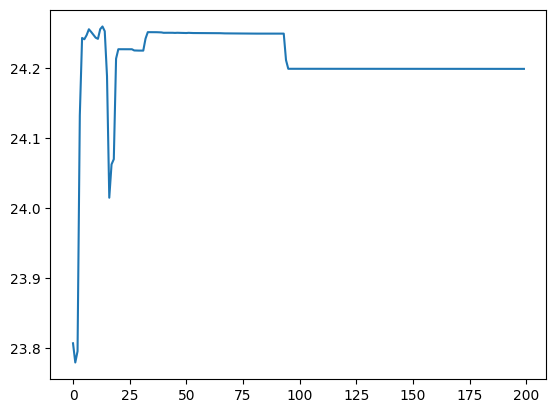

In [78]:
import matplotlib.pyplot as plt
plt.plot(mylosses)

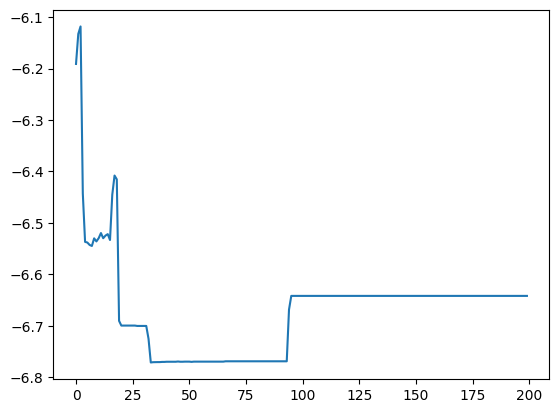

In [79]:
plt.plot(truelosses)